# nb22 - Gate/Huber ablation + timing-gated window scan

Two follow-ups from the advisor review of nb19/nb20:

1. **2x2 ablation** {gate on/off} x {Huber/MSE} on the timing (tok15) backbone at kNN-25 - the headline GateHuber changes *both* gating and loss vs Spacetime, so a reviewer cannot tell which helps. This isolates them.
2. **Timing-gated window scan** - train GateHuber at kNN in {25,40,60,81}. The nb21 oracle showed the calibrated *sum* degrades as the window grows (it cannot reject pileup); the real question is whether the gated model can exploit a larger window. If sigma_eff keeps dropping past 0.0485, there is a path toward the 0.03 goal; if it flattens/rises, 0.0485 is near the floor and the target must be renegotiated.

min-bias only, 3 seeds. Reuses the exact nb19 unified architecture.

In [1]:
import os, sys, pathlib, copy, time
import numpy as np, pandas as pd, uproot, awkward as ak, matplotlib.pyplot as plt
import torch, torch.nn as nn
REPO = pathlib.Path(os.environ['REPO_DIR']) if os.environ.get('REPO_DIR') else (
    pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd())
sys.path.insert(0, str(REPO / 'scripts'))
from run_experiments import select_knn, split, resolution, derive_geom, PITCH, EPS, CELL_KEYS
FILES = sorted((REPO / 'data' / 'minimum_bias').glob('matched_*.root'))
FIG = REPO / 'reports' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
OUT = REPO / 'reports' / 'predictions'; OUT.mkdir(parents=True, exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODE = os.environ.get('NB22_MODE', 'full')
print('device', DEVICE, '| mode', MODE, '|', len(FILES), 'files')

device cuda | mode full | 94 files


In [2]:
TKEYS = CELL_KEYS + ['cell_times_front', 'cell_times_back']
AUX = ['sig_flux_prod_vertex_z', 'sig_flux_eTot', 'total_energy']
def build_st(files, selector, vertex_max=100.0):
    O = {k: [] for k in ['tok12','tok15','R','agg','y','Etrue','region']}
    for path in files:
        with uproot.open(path) as f:
            a = f['clusters_matched'].arrays(TKEYS + AUX, library='ak')
        vz = ak.to_numpy(a['sig_flux_prod_vertex_z']).astype(float)
        for i in np.flatnonzero(vz < vertex_max):
            cc = {k: np.asarray(ak.to_numpy(a[k][i])).astype(float) for k in TKEYS}
            sel = selector(cc); cw = {k: v[sel] for k, v in cc.items()}
            e = cw['energy']
            if len(e) == 0: continue
            pitch, mod, rx, ry, rdr, seed = derive_geom(cw)
            fr = cw['cell_energies_front']; bk = cw['cell_energies_back']
            tf = cw['cell_times_front']; tb = cw['cell_times_back']
            vf = np.abs(tf) < 1e6; vb = np.abs(tb) < 1e6
            t0f = tf[seed] if vf[seed] else (np.median(tf[vf]) if vf.any() else 0.0)
            t0b = tb[seed] if vb[seed] else (np.median(tb[vb]) if vb.any() else 0.0)
            dtf = np.where(vf, tf - t0f, 0.0); dtb = np.where(vb, tb - t0b, 0.0)
            hasv = (vf | vb).astype(float)
            cont7 = np.stack([np.log1p(np.clip(e,0,None)), np.log1p(np.clip(fr,0,None)),
                              np.log1p(np.clip(bk,0,None)), rx/pitch, ry/pitch, rdr/pitch, np.log(pitch)], 1)
            oh = np.zeros((len(e), len(PITCH))); oh[np.arange(len(e)), mod] = 1.0
            O['tok12'].append(np.concatenate([cont7, oh], 1).astype(np.float32))
            O['tok15'].append(np.concatenate([cont7, dtf[:,None], dtb[:,None], hasv[:,None], oh], 1).astype(np.float32))
            O['R'].append(np.stack([rx/pitch, ry/pitch, np.log1p(np.clip(e,0,None)), dtf, hasv], 1).astype(np.float32))
            sumE = float(e.sum()); seedE = float(e[seed])
            lat = float(np.sqrt((e * rdr**2).sum() / (sumE + EPS))); fb = float(fr.sum() / (bk.sum() + EPS))
            O['agg'].append([np.log1p(sumE), fb, len(e), np.log1p(seedE), lat, int(mod[seed])])
            et = float(a['sig_flux_eTot'][i]); O['y'].append(np.log(max(et, 1e-3)))
            O['Etrue'].append(et); O['region'].append(int(mod[seed]))
    for k in ['agg','y','Etrue','region']: O[k] = np.array(O[k])
    return O

In [3]:
CFG = dict(d=96, nhead=4, layers=3, dropout=0.1, lr=3e-4, wd=1e-4, batch=256, pair_hidden=32, huber_delta=0.1)
N_GLOBAL = 5
def pair_features(R, use_time):
    rx, ry, le = R[..., 0], R[..., 1], R[..., 2]
    dx = rx.unsqueeze(2) - rx.unsqueeze(1); dy = ry.unsqueeze(2) - ry.unsqueeze(1)
    dR = torch.sqrt(dx*dx + dy*dy + 1e-6)
    esum = le.unsqueeze(2) + le.unsqueeze(1); emin = torch.minimum(le.unsqueeze(2), le.unsqueeze(1))
    feats = [dx, dy, dR, esum, emin]
    if use_time:
        dt = R[..., 3]; hv = R[..., 4]
        feats += [(dt.unsqueeze(2) - dt.unsqueeze(1)).abs() * (hv.unsqueeze(2) * hv.unsqueeze(1)),
                  hv.unsqueeze(2) * hv.unsqueeze(1)]
    return torch.stack(feats, -1)
class PairEmbed(nn.Module):
    def __init__(self, n_in, nhead, hidden):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, hidden), nn.GELU(), nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, nhead))
    def forward(self, pf): return self.net(pf).permute(0, 3, 1, 2).contiguous()
class PMHA(nn.Module):
    def __init__(self, d, nh, drop):
        super().__init__(); self.h = nh; self.dh = d // nh
        self.q = nn.Linear(d, d); self.k = nn.Linear(d, d); self.v = nn.Linear(d, d); self.o = nn.Linear(d, d); self.drop = nn.Dropout(drop)
    def forward(self, x, U, kv):
        B, L, d = x.shape
        q = self.q(x).view(B, L, self.h, self.dh).transpose(1, 2)
        k = self.k(x).view(B, L, self.h, self.dh).transpose(1, 2)
        v = self.v(x).view(B, L, self.h, self.dh).transpose(1, 2)
        s = (q @ k.transpose(-2, -1)) / (self.dh ** 0.5) + U
        s = s.masked_fill((~kv).view(B, 1, 1, L), -1e9)
        return self.o((self.drop(s.softmax(-1)) @ v).transpose(1, 2).reshape(B, L, d))
class Block(nn.Module):
    def __init__(self, d, nh, drop):
        super().__init__(); self.n1 = nn.LayerNorm(d); self.attn = PMHA(d, nh, drop); self.n2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, 4*d), nn.GELU(), nn.Dropout(drop), nn.Linear(4*d, d)); self.drop = nn.Dropout(drop)
    def forward(self, x, U, kv):
        x = x + self.drop(self.attn(self.n1(x), U, kv)); return x + self.drop(self.ff(self.n2(x)))
class PairT(nn.Module):
    def __init__(self, in_dim, use_time_pair=False, use_gate=False):
        super().__init__(); d = CFG['d']; self.use_time_pair = use_time_pair; self.use_gate = use_gate
        self.embed = nn.Linear(in_dim, d); self.pair = PairEmbed(7 if use_time_pair else 5, CFG['nhead'], CFG['pair_hidden'])
        self.blocks = nn.ModuleList([Block(d, CFG['nhead'], CFG['dropout']) for _ in range(CFG['layers'])])
        self.norm = nn.LayerNorm(d)
        self.head = nn.Sequential(nn.Linear(d + N_GLOBAL, d), nn.ReLU(), nn.Dropout(CFG['dropout']), nn.Linear(d, 1))
        if use_gate: self.gate = nn.Sequential(nn.Linear(2, 16), nn.GELU(), nn.Linear(16, 1))
    def forward(self, x, m, w, g, base, R):
        U = self.pair(pair_features(R, self.use_time_pair)); h = self.embed(x)
        for blk in self.blocks: h = blk(h, U, m)
        pw = w
        if self.use_gate:
            gate = torch.sigmoid(self.gate(R[..., 3:5]).squeeze(-1)) * m.float()
            pw = w * gate; pw = pw / pw.sum(1, keepdim=True).clamp(min=1e-9)
        p = self.norm((h * pw.unsqueeze(-1)).sum(1)); return base + self.head(torch.cat([p, g], 1))

### prep(N) - window-parameterised data build

In [4]:
def prep(N):
    O = build_st(FILES, lambda cc: select_knn(cc, N), 100.0)
    Nn = len(O['Etrue']); Et = O['Etrue']; y = O['y'].astype(np.float32); agg = O['agg']
    keep = np.flatnonzero((Et >= 1.0) & (Et <= 100.0))
    ktr, kva, kte = (keep[s] for s in split(len(keep)))
    G = np.stack([agg[:,0], agg[:,3], np.log(agg[:,2]+1.0), agg[:,1], agg[:,4]], 1).astype(np.float32)
    G = (G - G[ktr].mean(0)) / (G[ktr].std(0) + EPS)
    la, lb = np.polyfit(agg[ktr,0], y[ktr], 1); base_all = (la*agg[:,0] + lb).astype(np.float32)
    maxL = max(t.shape[0] for t in O['tok15'])
    def pad(toks, F):
        A = np.zeros((Nn, maxL, F), np.float32)
        for i, t in enumerate(toks): A[i, :t.shape[0]] = t
        return A
    X15 = pad(O['tok15'], 15); Rp = pad(O['R'], 5)
    M = np.zeros((Nn, maxL), np.bool_); W = np.zeros((Nn, maxL), np.float32)
    for i, t in enumerate(O['tok12']):
        L = t.shape[0]; M[i, :L] = True
        e = np.expm1(np.clip(t[:,0], 0, None)); W[i, :L] = e / (e.sum() + 1e-9)
    cont = X15[ktr][:, :, :9].reshape(-1, 9)[M[ktr].reshape(-1)]
    mean = cont.mean(0); std = cont.std(0) + EPS
    X15 = X15.copy(); X15[:, :, :9] = (X15[:, :, :9] - mean) / std; X15[~M] = 0.0
    t = lambda z: torch.from_numpy(z).to(DEVICE)
    P = dict(X15=t(X15), R=t(Rp), M=t(M), W=t(W), G=t(G), base=t(base_all).unsqueeze(1),
             y=t(y).unsqueeze(1), ktr=ktr, kva=kva, kte=kte, Et=Et)
    print(f'N={N} clusters={Nn} kept={len(keep)} maxL={maxL} test={len(kte)}', flush=True)
    return P

### train_eval - gate/time-pair/loss configurable

In [5]:
def train_eval(spec, P, seed):
    torch.manual_seed(seed); rng = np.random.default_rng(seed)
    model = PairT(15, spec.get('use_time_pair', False), spec.get('use_gate', False)).to(DEVICE)
    huber = spec['loss'] == 'huber'
    opt = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['wd'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    def fwd(b): return model(P['X15'][b], P['M'][b], P['W'][b], P['G'][b], P['base'][b], P['R'][b])
    def lossf(p, t): return nn.functional.huber_loss(p, t, delta=CFG['huber_delta']) if huber else nn.functional.mse_loss(p, t)
    def batches(idx, bs, sh):
        idx = np.asarray(idx)
        if sh: idx = rng.permutation(idx)
        for j in range(0, len(idx), bs): yield torch.from_numpy(idx[j:j+bs]).to(DEVICE)
    def run(idx):
        out = []
        with torch.no_grad():
            for b in batches(idx, 512, False): out.append(fwd(b).cpu().numpy().ravel())
        return np.concatenate(out)
    def vloss():
        model.eval(); s = 0.0; n = 0
        with torch.no_grad():
            for b in batches(P['kva'], 512, False): s += lossf(fwd(b), P['y'][b]).item(); n += 1
        return s / max(n, 1)
    best = 1e9; bstate = None; wait = 0
    for ep in range(EPOCHS):
        model.train()
        for b in batches(P['ktr'], CFG['batch'], True):
            opt.zero_grad(); lossf(fwd(b), P['y'][b]).backward(); opt.step()
        sched.step(); vv = vloss()
        if vv < best - 1e-4: best = vv; bstate = copy.deepcopy(model.state_dict()); wait = 0
        else:
            wait += 1
            if wait >= PATIENCE: break
    model.load_state_dict(bstate); model.eval()
    a, b = np.polyfit(run(P['kva']), P['y'].cpu().numpy().ravel()[P['kva']], 1)
    pe = np.exp(a * run(P['kte']) + b)
    return float(resolution(pe, P['Et'][P['kte']])['sigma_eff'])

### Run: ablation (kNN-25) + window scan
The gate-on + Huber config at N=25 is the nb19 GateHuber and doubles as the N=25 point of the window scan.

In [6]:
SEEDS = {'smoke': [0], 'full': [0, 1, 2]}[MODE]
EPOCHS = {'smoke': 3, 'full': 150}[MODE]
PATIENCE = {'smoke': 99, 'full': 25}[MODE]
WINDOWS = {'smoke': [25], 'full': [25, 40, 60, 81]}[MODE]
ABL = [('gate0_mse', dict(use_gate=False, loss='mse')),
       ('gate1_mse', dict(use_gate=True, loss='mse')),
       ('gate0_huber', dict(use_gate=False, loss='huber')),
       ('gate1_huber', dict(use_gate=True, loss='huber'))]
GATEHUBER = dict(use_gate=True, loss='huber')
CSVP = OUT / 'nb22_ablation_window.csv'
done = set()
if CSVP.exists():
    prev = pd.read_csv(CSVP)
    prev = prev[prev['seeds'] == len(SEEDS)]
    prev.to_csv(CSVP, index=False)
    done = set(zip(prev['N'].tolist(), prev['config'].tolist()))
    print('resume: already done =', sorted(done), flush=True)
def record(row):
    hdr = (not CSVP.exists()) or CSVP.stat().st_size == 0
    pd.DataFrame([row]).to_csv(CSVP, mode='a', header=hdr, index=False)
for N in WINDOWS:
    todo = ABL if N == 25 else [('gate1_huber', GATEHUBER)]
    todo = [(nm, sp) for nm, sp in todo if (N, nm) not in done]
    if not todo:
        print(f'skip N={N} (all done)', flush=True); continue
    CFG['batch'] = 128 if N >= 60 else 256
    P = prep(N)
    for name, spec in todo:
        sd = [train_eval(spec, P, s) for s in SEEDS]
        row = dict(N=N, config=name, sigma_eff=round(float(np.mean(sd)), 4),
                   std=round(float(np.std(sd)), 4), seeds=len(SEEDS))
        record(row)
        print(f'  N={N} {name:12s} sigma_eff {np.mean(sd):.4f} +/- {np.std(sd):.4f}  (batch {CFG["batch"]})', flush=True)
    del P
    if DEVICE == 'cuda': torch.cuda.empty_cache()
RES = pd.read_csv(CSVP)
print(RES.to_string(index=False)); print('DONE mode=' + MODE)

resume: already done = [(25, 'gate0_huber'), (25, 'gate0_mse'), (25, 'gate1_huber'), (25, 'gate1_mse'), (40, 'gate1_huber'), (60, 'gate1_huber'), (81, 'gate1_huber')]


skip N=25 (all done)


skip N=40 (all done)


skip N=60 (all done)


skip N=81 (all done)


 N      config  sigma_eff    std  seeds
25   gate0_mse     0.0564 0.0005      3
25   gate1_mse     0.0565 0.0014      3
25 gate0_huber     0.0484 0.0001      3
25 gate1_huber     0.0483 0.0010      3
40 gate1_huber     0.0480 0.0002      3
60 gate1_huber     0.0473 0.0006      3
81 gate1_huber     0.0459 0.0008      3
DONE mode=full


### Ablation table + window-scan plot

=== 2x2 ablation (kNN-25) ===
           MSE     Huber
no-gate  0.0564  0.0484
gate     0.0565  0.0483


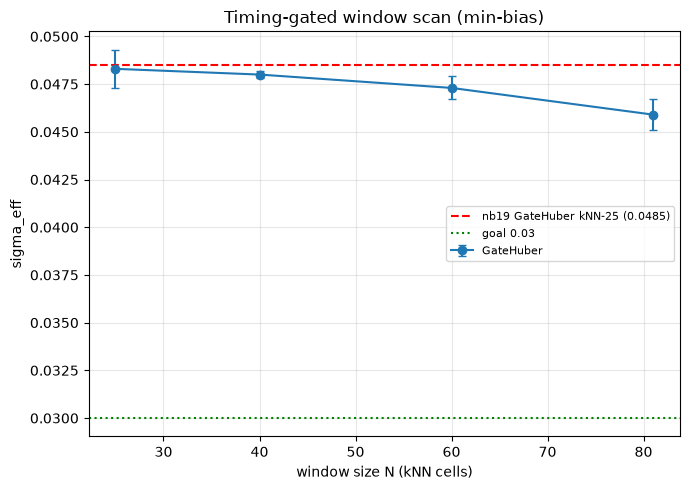

In [7]:
abl = RES[RES.N == 25].set_index('config')['sigma_eff']
print('=== 2x2 ablation (kNN-25) ===')
print(f"           MSE     Huber")
print(f"no-gate  {abl.get('gate0_mse',float('nan')):.4f}  {abl.get('gate0_huber',float('nan')):.4f}")
print(f"gate     {abl.get('gate1_mse',float('nan')):.4f}  {abl.get('gate1_huber',float('nan')):.4f}")
gh = RES[RES.config == 'gate1_huber'].sort_values('N')
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(gh['N'], gh['sigma_eff'], yerr=gh['std'], marker='o', capsize=3, label='GateHuber')
ax.axhline(0.0485, ls='--', color='r', label='nb19 GateHuber kNN-25 (0.0485)')
ax.axhline(0.03, ls=':', color='g', label='goal 0.03')
ax.set_xlabel('window size N (kNN cells)'); ax.set_ylabel('sigma_eff')
ax.set_title('Timing-gated window scan (min-bias)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(FIG / 'fig7_window_scan.png', dpi=130); plt.show()